In [1]:
import numpy as np

from triqs.gf import *
from triqs.plot.mpl_interface import *
import matplotlib as mpl
from h5 import *

In [2]:
with HDFArchive("data/ed_bethe.h5", 'r') as A:
    print(A.keys())

['U0.00', 'U1.00', 'U2.00', 'U3.00', 'U4.00', 'U5.00', 'U6.00', 'U7.00', 'U8.00', 'U9.00']


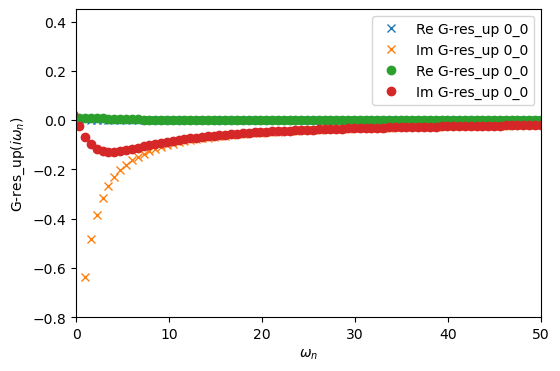

In [3]:
plt.figure(figsize=(6, 4))
with HDFArchive("data/ed_bethe.h5", 'r') as A:
    oplot(A['U0.00']['G-res']['up'], 'x')
    oplot(A['U8.00']['G-res']['up'], 'o')

plt.xlim(0,50)
plt.ylim(-0.8, 0.45)
plt.show()

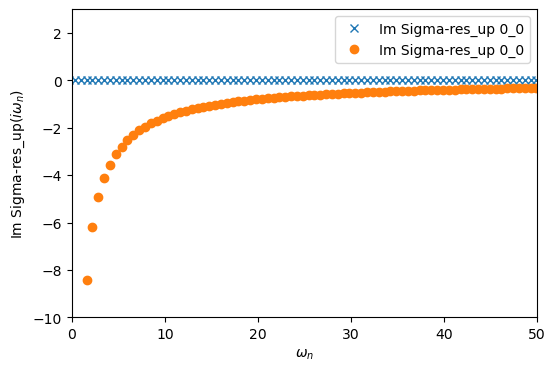

In [4]:
plt.figure(figsize=(6, 4))
with HDFArchive("data/ed_bethe.h5", 'r') as A:
    oplot(A['U0.00']['Sigma-res']['up'].imag, 'x')
    oplot(A['U8.00']['Sigma-res']['up'].imag, 'o')

plt.xlim(0,50)
plt.ylim(-10, 3)
plt.show()

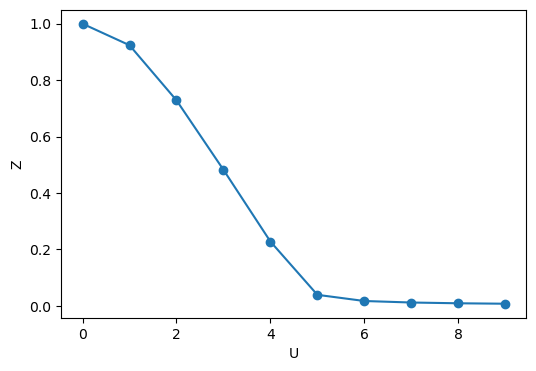

In [5]:
beta = 10

U_list = []
Z_list = []
for U in np.arange(0.0, 10.0, 1.0):
    with HDFArchive("data/ed_bethe.h5", 'r') as A:
        Sigma = A[f'U{U:.2f}']['Sigma-res']

        Z = 1 / (1 - (Sigma['up'](0)[0,0].imag * beta / np.pi))
        U_list.append(U)
        Z_list.append(Z)

plt.figure(figsize=(6, 4))
plt.plot(U_list, Z_list, '-o')
plt.xlabel('U')
plt.ylabel('Z')
plt.show()

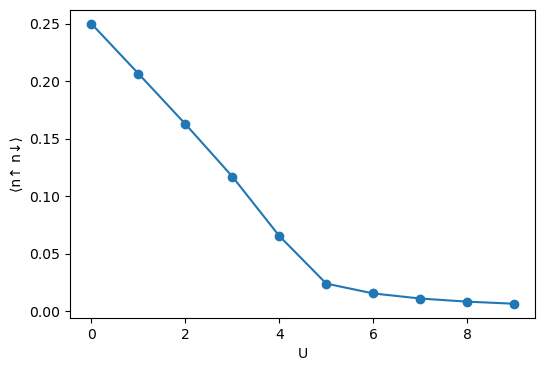

In [6]:
double_occup_list = []
U_list = []

with HDFArchive("data/ed_bethe.h5", 'r') as A:
    for U in np.arange(0.0, 10.0, 1.0):
        double_occup_list.append(A[f'U{U:.2f}']['double_occupancy'])
        U_list.append(U)
    
plt.figure(figsize=(6, 4))
plt.plot(U_list, double_occup_list, '-o')
plt.xlabel('U')
plt.ylabel('⟨n↑ n↓⟩')
plt.show()